In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_train.parquet
/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_test.parquet


In [5]:
import pandas as pd

train = pd.read_parquet("/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_train.parquet")
test = pd.read_parquet("/kaggle/input/datasets/bharanikumar55/bbc-hindi-dataset/bbc_test.parquet")

## TEXT PREPROCESSING

In [10]:
import re

def clean_text(text):
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Keep only Hindi characters
    text = re.sub(r'[^\u0900-\u097F\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [11]:
train['clean_text'] = train['text'].apply(clean_text)
test['clean_text'] = test['text'].apply(clean_text)

In [12]:
train.head()

,label,text,clean_text
0,india,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...
1,pakistan,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...
2,news,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...
3,india,"प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ...",प्रतीक खुलेपन का आज़ाद ख्याली का और भीड़ से अल...
4,india,ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...,ख़ासकर पिछले साल तक प्रधानमंत्री रहे मनमोहन सि...


In [13]:
train['tokens'] = train['clean_text'].apply(lambda x: x.split())
test['tokens'] = test['clean_text'].apply(lambda x: x.split())

In [14]:
train.head()


,label,text,clean_text,tokens
0,india,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,"[मेट्रो, की, इस, लाइन, के, चलने, से, दक्षिणी, ..."
1,pakistan,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,"[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब..."
2,news,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,"[इसमें, एक, फ़्लाइट, एटेनडेंट, की, मदद, की, गु..."
3,india,"प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ...",प्रतीक खुलेपन का आज़ाद ख्याली का और भीड़ से अल...,"[प्रतीक, खुलेपन, का, आज़ाद, ख्याली, का, और, भी..."
4,india,ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...,ख़ासकर पिछले साल तक प्रधानमंत्री रहे मनमोहन सि...,"[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन..."


In [17]:
stopwords = ['है', 'और', 'में', 'को', 'का', 'की']

In [28]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

train['tokens_stopword_removal'] = train['tokens'].apply(remove_stopwords)
test['tokens_stopword_removal'] = test['tokens'].apply(remove_stopwords)

In [19]:
train.head()

,label,text,clean_text,tokens,tokens_stopword_removal
0,india,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,"[मेट्रो, की, इस, लाइन, के, चलने, से, दक्षिणी, ...","[मेट्रो, इस, लाइन, के, चलने, से, दक्षिणी, दिल्..."
1,pakistan,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,"[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब...","[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब..."
2,news,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,"[इसमें, एक, फ़्लाइट, एटेनडेंट, की, मदद, की, गु...","[इसमें, एक, फ़्लाइट, एटेनडेंट, मदद, गुहार, साथ..."
3,india,"प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ...",प्रतीक खुलेपन का आज़ाद ख्याली का और भीड़ से अल...,"[प्रतीक, खुलेपन, का, आज़ाद, ख्याली, का, और, भी...","[प्रतीक, खुलेपन, आज़ाद, ख्याली, भीड़, से, अलग,..."
4,india,ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...,ख़ासकर पिछले साल तक प्रधानमंत्री रहे मनमोहन सि...,"[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन...","[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन..."


In [20]:
!pip install gensim

In [22]:
from gensim.models import FastText
import numpy as np

In [23]:
sentences = train['tokens_stopword_removal'].tolist()

In [24]:
fasttext_model = FastText(
    sentences,
    vector_size=100,   # size of word vectors
    window=5,          # context size
    min_count=1,       # include all words
    workers=4
)

In [61]:
fasttext_model_inc = FastText(
    sentences,
    vector_size=100,   # size of word vectors
    window=5,          # context size
    min_count=1,       # include all words
    workers=4
)

In [26]:
def get_sentence_vector(tokens, model):
    vectors = []
    
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

## SAME FOR TEST SET


In [62]:
train['fasttext_vector_inc'] = train['tokens_stopword_removal'].apply(
    lambda x: get_sentence_vector(x, fasttext_model_inc)
)

test['fasttext_vector_inc'] = test['tokens_stopword_removal'].apply(
    lambda x: get_sentence_vector(x, fasttext_model_inc)
)

In [63]:
train['fasttext_vector_no_stop_inc'] = train['tokens'].apply(
    lambda x: get_sentence_vector(x, fasttext_model_inc)
)

test['fasttext_vector_no_stop_inc'] = test['tokens'].apply(
    lambda x: get_sentence_vector(x, fasttext_model_inc)
)

In [64]:
train.head()

,label,text,clean_text,tokens,tokens_stopword_removal,fasttext_vector,fasttext_vector_no_stop,fasttext_vector_inc,fasttext_vector_no_stop_inc
0,india,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,मेट्रो की इस लाइन के चलने से दक्षिणी दिल्ली से...,"[मेट्रो, की, इस, लाइन, के, चलने, से, दक्षिणी, ...","[मेट्रो, इस, लाइन, के, चलने, से, दक्षिणी, दिल्...","[0.03336984, -0.361584, -0.38841558, -0.332631...","[-0.04081429, -0.49776703, -0.45304623, -0.371...","[0.19482976, -0.31700793, -0.1834118, -1.00045...","[0.19094805, -0.38100055, -0.16458504, -1.1614..."
1,pakistan,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,नेटिजन यानि इंटरनेट पर सक्रिय नागरिक अब ट्विटर...,"[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब...","[नेटिजन, यानि, इंटरनेट, पर, सक्रिय, नागरिक, अब...","[-0.5283313, -0.52763146, -0.22807933, -0.1821...","[-0.42513767, -0.59535635, -0.23261361, -0.326...","[-0.4261212, -0.32635698, -0.077340804, -0.579...","[-0.2944218, -0.39716652, -0.074407175, -0.804..."
2,news,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,इसमें एक फ़्लाइट एटेनडेंट की मदद की गुहार है औ...,"[इसमें, एक, फ़्लाइट, एटेनडेंट, की, मदद, की, गु...","[इसमें, एक, फ़्लाइट, एटेनडेंट, मदद, गुहार, साथ...","[-0.14598867, -0.40529454, -0.3603626, -0.1814...","[-0.15906301, -0.51145536, -0.40823597, -0.286...","[0.14335592, -0.28425395, -0.17236052, -0.7115...","[0.16511773, -0.36298084, -0.121303454, -0.958..."
3,india,"प्रतीक खुलेपन का, आज़ाद ख्याली का और भीड़ से अ...",प्रतीक खुलेपन का आज़ाद ख्याली का और भीड़ से अल...,"[प्रतीक, खुलेपन, का, आज़ाद, ख्याली, का, और, भी...","[प्रतीक, खुलेपन, आज़ाद, ख्याली, भीड़, से, अलग,...","[-0.08891013, -0.49659184, -0.5321046, -0.3495...","[-0.121091686, -0.6367781, -0.56880325, -0.378...","[-0.041393295, -0.38360804, -0.4651376, -1.014...","[-0.01349237, -0.47420332, -0.44709435, -1.158..."
4,india,ख़ासकर पिछले 10 साल तक प्रधानमंत्री रहे मनमोहन...,ख़ासकर पिछले साल तक प्रधानमंत्री रहे मनमोहन सि...,"[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन...","[ख़ासकर, पिछले, साल, तक, प्रधानमंत्री, रहे, मन...","[-0.24493544, -0.048001338, -0.4289564, -0.406...","[-0.17554608, -0.14038394, -0.42722106, -0.516...","[-0.19412953, 0.07413587, -0.27588534, -0.8813...","[-0.10536158, -0.016096542, -0.2755419, -1.061..."


In [31]:
X_train = np.vstack(train['fasttext_vector'].values)
X_test = np.vstack(test['fasttext_vector'].values)


In [54]:
X_train_n = np.vstack(train['fasttext_vector_no_stop'].values)
X_test_n = np.vstack(test['fasttext_vector_no_stop'].values)


In [65]:
X_train_inc = np.vstack(train['fasttext_vector_no_stop_inc'].values)
X_test_inc = np.vstack(test['fasttext_vector_no_stop_inc'].values)


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim

In [33]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [34]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder (compress)
        self.encoder = nn.Sequential(
            nn.Linear(100, 64),
            nn.ReLU(),
            nn.Linear(64, 32)   # LATENT SPACE
        )
        
        # Decoder (reconstruct)
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 100)
        )
    
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

In [35]:
model = Autoencoder()

In [36]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [37]:
epochs = 20

for epoch in range(epochs):
    
    optimizer.zero_grad()
    
    output = model(X_train_tensor)
    
    loss = criterion(output, X_train_tensor)
    
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.32330167293548584
Epoch 2, Loss: 0.31413403153419495
Epoch 3, Loss: 0.30622488260269165
Epoch 4, Loss: 0.2989037334918976
Epoch 5, Loss: 0.29172173142433167
Epoch 6, Loss: 0.28435060381889343
Epoch 7, Loss: 0.27639925479888916
Epoch 8, Loss: 0.2676721215248108
Epoch 9, Loss: 0.25811734795570374
Epoch 10, Loss: 0.24770069122314453
Epoch 11, Loss: 0.23641526699066162
Epoch 12, Loss: 0.22435809671878815
Epoch 13, Loss: 0.21173898875713348
Epoch 14, Loss: 0.1988781988620758
Epoch 15, Loss: 0.18611586093902588
Epoch 16, Loss: 0.17385470867156982
Epoch 17, Loss: 0.1625801920890808
Epoch 18, Loss: 0.15256521105766296
Epoch 19, Loss: 0.14370977878570557
Epoch 20, Loss: 0.13546153903007507


In [38]:
with torch.no_grad():
    latent_train = model.encoder(X_train_tensor)
    latent_test = model.encoder(X_test_tensor)

In [40]:
latent_train.shape

torch.Size([3467, 32])

In [41]:
latent_train_np = latent_train.numpy()
latent_test_np = latent_test.numpy()

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(train['label'])
y_test = le.transform(test['label'])

In [43]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))

## Autoencoder plus classification with stopword removal

In [44]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(latent_train_np, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [45]:
y_pred = clf.predict(latent_test_np)

In [78]:
from sklearn.metrics import accuracy_score, classification_report
fasttext_ae_acc=accuracy_score(y_test, y_pred)
print("Accuracy:",fasttext_ae_acc)
print(classification_report(y_test, y_pred))

Accuracy: 0.2840646651270208
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.03      0.20      0.06         5
           2       0.57      0.73      0.64        71
           3       0.85      0.25      0.39       357
           4       0.07      0.50      0.12         4
           5       0.44      0.09      0.16       212
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.07      0.02      0.03        49
           9       0.02      0.25      0.04         8
          10       0.24      0.41      0.30        61
          11       0.07      0.83      0.13         6
          12       0.06      0.40      0.10        10
          13       0.49      0.62      0.55        72

    accuracy                           0.28       866
   macro avg       0.21      0.31      0.18       866
weighted avg       0.57      0.28      0.32       8

## Stopword removal and classification

In [49]:
from sklearn.linear_model import LogisticRegression

clf_n = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_n.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [50]:
y_pred_n = clf_n.predict(X_test)

In [77]:
from sklearn.metrics import accuracy_score, classification_report
fasttext_logacc=accuracy_score(y_test, y_pred_n)
print("Accuracy:",fasttext_logacc)
print(classification_report(y_test, y_pred_n))

Accuracy: 0.5496535796766744
              precision    recall  f1-score   support

           0       0.10      0.43      0.16         7
           1       0.05      0.20      0.08         5
           2       0.65      0.77      0.71        71
           3       0.88      0.54      0.66       357
           4       0.14      0.75      0.23         4
           5       0.73      0.44      0.55       212
           6       0.00      0.00      0.00         3
           7       0.04      1.00      0.07         1
           8       0.21      0.24      0.23        49
           9       0.08      0.38      0.13         8
          10       0.49      0.80      0.61        61
          11       0.12      0.83      0.20         6
          12       0.12      0.40      0.19        10
          13       0.85      0.78      0.81        72

    accuracy                           0.55       866
   macro avg       0.32      0.54      0.33       866
weighted avg       0.71      0.55      0.60       8

## No Stopword removal just fasttext and classification

In [55]:
from sklearn.linear_model import LogisticRegression

clf_new = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_new.fit(X_train_n, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [59]:
y_pred_new = clf_new.predict(X_test_n)

In [60]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

Accuracy: 0.5150115473441108
              precision    recall  f1-score   support

           0       0.10      0.43      0.16         7
           1       0.05      0.20      0.08         5
           2       0.69      0.77      0.73        71
           3       0.85      0.50      0.63       357
           4       0.12      0.75      0.21         4
           5       0.71      0.39      0.50       212
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.20      0.24      0.22        49
           9       0.08      0.38      0.13         8
          10       0.45      0.79      0.57        61
          11       0.12      0.83      0.20         6
          12       0.08      0.30      0.12        10
          13       0.83      0.74      0.78        72

    accuracy                           0.52       866
   macro avg       0.30      0.45      0.31       866
weighted avg       0.70      0.52      0.57       8

## No Stopword removal plus vector size=200

In [66]:
from sklearn.linear_model import LogisticRegression

clf_inc = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_inc.fit(X_train_inc, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [68]:
y_pred_inc=clf_inc.predict(X_test_inc)

In [69]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_inc))
print(classification_report(y_test, y_pred_inc))

Accuracy: 0.5173210161662818
              precision    recall  f1-score   support

           0       0.05      0.29      0.09         7
           1       0.06      0.20      0.09         5
           2       0.71      0.77      0.74        71
           3       0.86      0.50      0.63       357
           4       0.11      0.75      0.19         4
           5       0.71      0.39      0.50       212
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.26      0.33      0.29        49
           9       0.07      0.38      0.12         8
          10       0.46      0.77      0.58        61
          11       0.12      0.83      0.21         6
          12       0.08      0.30      0.12        10
          13       0.82      0.74      0.77        72

    accuracy                           0.52       866
   macro avg       0.31      0.45      0.31       866
weighted avg       0.71      0.52      0.57       8

## USING SVM

In [76]:
from sklearn.svm import SVC

svm_model = SVC(class_weight='balanced')

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
fasttext_svm=accuracy_score(y_test, y_pred_svm)
print("Accuracy:",fasttext_svm)
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.4491916859122402
              precision    recall  f1-score   support

           0       0.07      0.43      0.12         7
           1       0.00      0.00      0.00         5
           2       0.63      0.80      0.71        71
           3       0.86      0.39      0.53       357
           4       0.11      0.75      0.19         4
           5       0.57      0.32      0.41       212
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.20      0.24      0.22        49
           9       0.05      0.25      0.08         8
          10       0.33      0.74      0.45        61
          11       0.12      1.00      0.22         6
          12       0.14      0.60      0.23        10
          13       0.85      0.69      0.76        72

    accuracy                           0.45       866
   macro avg       0.28      0.44      0.28       866
weighted avg       0.66      0.45      0.49       8

In [72]:
from sklearn.svm import SVC

svm_model_n = SVC(class_weight='balanced')

svm_model_n.fit(X_train_n, y_train)

y_pred_svm_n = svm_model_n.predict(X_test_n)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_svm_n))
print(classification_report(y_test, y_pred_svm_n))

Accuracy: 0.3960739030023095
              precision    recall  f1-score   support

           0       0.02      0.14      0.04         7
           1       0.00      0.00      0.00         5
           2       0.59      0.76      0.66        71
           3       0.82      0.34      0.48       357
           4       0.12      0.75      0.20         4
           5       0.50      0.24      0.32       212
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         1
           8       0.22      0.20      0.21        49
           9       0.04      0.25      0.06         8
          10       0.31      0.74      0.44        61
          11       0.10      0.83      0.18         6
          12       0.09      0.40      0.14        10
          13       0.86      0.67      0.75        72

    accuracy                           0.40       866
   macro avg       0.26      0.38      0.25       866
weighted avg       0.62      0.40      0.44       8

## TF-IDF

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(train['clean_text'])
X_test_tfidf = vectorizer.transform(test['clean_text'])

from sklearn.svm import SVC

svm = SVC(class_weight='balanced')

svm.fit(X_train_tfidf, y_train)

y_pred_tf = svm.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score
tfidf_svm_acc=accuracy_score(y_test, y_pred_tf)

print("Accuracy:",tfidf_svm_acc)

Accuracy: 0.7251732101616628


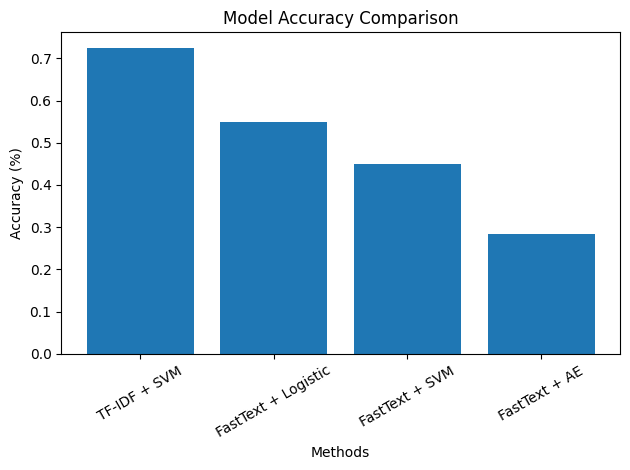

In [79]:
import matplotlib.pyplot as plt

methods = [
    "TF-IDF + SVM",
    "FastText + Logistic",
    "FastText + SVM",
    "FastText + AE"
]

accuracy = [tfidf_svm_acc,fasttext_logacc,fasttext_svm,fasttext_ae_acc]

plt.figure()
plt.bar(methods, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Methods")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

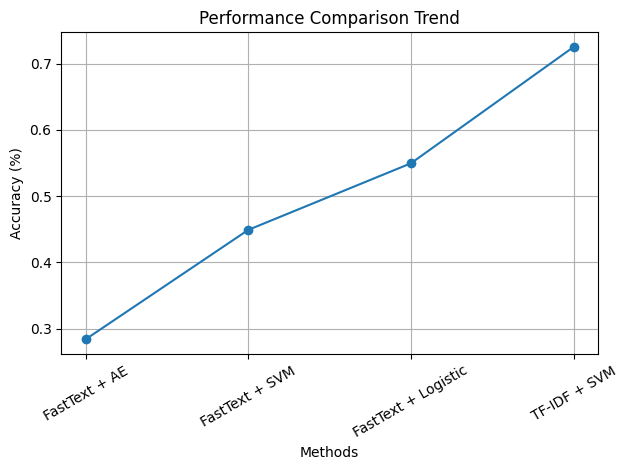

In [83]:
import matplotlib.pyplot as plt

methods = [
    "TF-IDF + SVM",
    "FastText + Logistic",
    "FastText + SVM",
    "FastText + AE"
]
methods=methods[::-1]
accuracy = [tfidf_svm_acc,fasttext_logacc,fasttext_svm,fasttext_ae_acc]
accuracy=accuracy[::-1]
plt.figure()
plt.plot(methods, accuracy, marker='o')

plt.title("Performance Comparison Trend")
plt.xlabel("Methods")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=30)
plt.grid()
plt.tight_layout()

plt.show()

## tfidf with ngram and svm

In [94]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer1 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3)   # unigram + bigram
)

X_train_tfidf_n = vectorizer1.fit_transform(train['clean_text'])
X_test_tfidf_n = vectorizer1.transform(test['clean_text'])

In [95]:
from sklearn.svm import SVC

svm_tf = SVC(class_weight='balanced')

svm_tf.fit(X_train_tfidf_n, y_train)

y_pred_tfidf_n= svm_tf.predict(X_test_tfidf_n)

In [96]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_tfidf_n))

Accuracy: 0.7205542725173211
